# Giai đoạn 4 — So sánh mô hình & khuyến nghị (bản hoàn thiện)

Dùng lại **khung nested CV trung thực** của Giai đoạn 3 để so k-NN+DE (bài báo) với các mô hình hiện đại, **trên cùng một quy trình**. Bản này bổ sung đúng những gì còn thiếu để đưa ra khuyến nghị vững:

1. **Không chỉ accuracy.** Bài toán mìn mất cân bằng và an toàn tính mạng → phát hiện phải đo **recall lớp "có mìn", precision, F1** và **đường cong PR** để chọn ngưỡng; phân loại đo thêm **macro-F1**.
2. **k-NN+DE có chọn mô hình** (k, độ đo) như GĐ3, `polish=False` — nhất quán, không rò rỉ.
3. **Kiểm định thống kê** (Friedman + Wilcoxon) và **bảng khuyến nghị mô hình** kèm lý do.

Nguyên tắc: *mọi mô hình qua cùng một khung đánh giá.*

## 1. Chuẩn bị & tự phát hiện thư viện boosting

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier)
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             precision_recall_curve, average_precision_score)
from scipy.optimize import differential_evolution
from scipy.stats import friedmanchisquare, wilcoxon
import os

RANDOM_STATE = 42
K_VALUES = [2, 3, 4, 5]
METRICS  = ["EU", "MA", "MI"]
os.makedirs("../result/figures", exist_ok=True)

HAS = {}
for lib in ["lightgbm", "xgboost", "catboost"]:
    try: __import__(lib); HAS[lib] = True
    except Exception: HAS[lib] = False
print("Thư viện boosting:", HAS, "(False -> thay bằng HistGBM của sklearn)")

Thư viện boosting: {'lightgbm': True, 'xgboost': True, 'catboost': True} (False -> thay bằng HistGBM của sklearn)


## 2. Nạp dữ liệu

In [2]:
try:
    df = pd.read_excel("../Data/Mine_Dataset_main.xls", engine="xlrd")
except Exception:
    df = pd.read_excel("../Data/Mine_Dataset_main.xls")
df.columns = [str(c).strip() for c in df.columns]
if list(df.columns[:4]) != ["V","H","S","M"]:
    df = df.rename(columns=dict(zip(df.columns[:4], ["V","H","S","M"])))
df["M"] = df["M"].astype(int)
X_all    = df[["V","H","S"]].values.astype(float)
y_detect = (df["M"] != 1).astype(int).values   # 1 = có mìn
y_class  = df["M"].values
print("Đã nạp:", df.shape, "| phát hiện:", np.bincount(y_detect))

Đã nạp: (338, 4) | phát hiện: [ 71 267]


## 3. Danh sách mô hình + k-NN+DE có chọn mô hình

Mỗi mô hình là factory (bản mới mỗi fold). Boosting ưu tiên bản xịn (LightGBM/XGBoost/CatBoost), fallback HistGBM. k-NN+DE dùng `select_and_weight` như GĐ3 (chọn k, độ đo, trọng số trên validation; `polish=False`).

In [3]:
def build_factories():
    f = {
        "LogReg":       lambda: LogisticRegression(max_iter=1000),
        "kNN":          lambda: KNeighborsClassifier(n_neighbors=4),
        "MLP":          lambda: MLPClassifier(hidden_layer_sizes=(16,8), max_iter=1500,
                                              random_state=RANDOM_STATE),
        "RandomForest": lambda: RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
        "ExtraTrees":   lambda: ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE),
    }
    if HAS["lightgbm"]:
        from lightgbm import LGBMClassifier
        f["LightGBM"] = lambda: LGBMClassifier(n_estimators=300, verbose=-1, random_state=RANDOM_STATE)
    else:
        f["GBM(HistGBM)"] = lambda: HistGradientBoostingClassifier(random_state=RANDOM_STATE)
    if HAS["xgboost"]:
        from xgboost import XGBClassifier
        f["XGBoost"] = lambda: XGBClassifier(n_estimators=300, eval_metric="mlogloss",
                                             random_state=RANDOM_STATE)
    if HAS["catboost"]:
        from catboost import CatBoostClassifier
        f["CatBoost"] = lambda: CatBoostClassifier(iterations=300, verbose=0, random_state=RANDOM_STATE)
    return f

# --- k-NN có trọng số + DE (Phase 3 consistent) ---
def _pred(Xtr, ytr, Xte, k, m, w=None):
    if w is not None: Xtr, Xte = Xtr*w, Xte*w
    p = {"EU":2,"MA":1,"MI":3}[m]
    return KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=p).fit(Xtr, ytr).predict(Xte)
def _acc(Xtr, ytr, Xe, ye, k, m, w=None): return accuracy_score(ye, _pred(Xtr,ytr,Xe,k,m,w))
def de_weights(Xtr, ytr, Xf, yf, k, m):
    r = differential_evolution(lambda w: -_acc(Xtr,ytr,Xf,yf,k,m,w),
        [(0,1)]*Xtr.shape[1], maxiter=15, popsize=6, seed=RANDOM_STATE, tol=1e-3, polish=False)
    return r.x, -r.fun
def select_and_weight(Xtr, ytr, Xv, yv):
    best = (-1, None, None, None)
    for k in K_VALUES:
        for m in METRICS:
            w, a = de_weights(Xtr, ytr, Xv, yv, k, m)
            if a > best[0]: best = (a, k, m, w)
    return best[1], best[2], best[3]
def wknn_fit_predict(Xtr, ytr, Xte):
    Xit, Xiv, yit, yiv = train_test_split(Xtr, ytr, test_size=0.25, stratify=ytr, random_state=RANDOM_STATE)
    k, m, w = select_and_weight(Xit, yit, Xiv, yiv)
    return _pred(Xtr, ytr, Xte, k, m, w)

print("Mô hình:", list(build_factories().keys()) + ["kNN+DE"])

Mô hình: ['LogReg', 'kNN', 'MLP', 'RandomForest', 'ExtraTrees', 'LightGBM', 'XGBoost', 'CatBoost', 'kNN+DE']


## 4. Khung đánh giá chung — nhiều chỉ số

Trả về **mảng điểm từng fold** cho mỗi mô hình. Phát hiện: accuracy, recall (lớp có mìn), precision, F1. Phân loại: accuracy, macro-F1. Chuẩn hóa fit trên train mỗi fold. XGBoost cần nhãn 0-based (xử lý riêng).

In [4]:
def evaluate(X, y, task, n_splits=5, n_repeats=3):
    outer = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE)
    facs = build_factories(); names = list(facs) + ["kNN+DE"]
    keys = ["acc","rec","prec","f1"] if task=="detect" else ["acc","f1"]
    rec = {n: {kk: [] for kk in keys} for n in names}
    remap = {c:i for i,c in enumerate(np.unique(y))}
    y0 = np.vectorize(remap.get)(y)

    def add(n, yte, pr):
        rec[n]["acc"].append(accuracy_score(yte, pr))
        if task=="detect":
            rec[n]["rec"].append(recall_score(yte, pr, pos_label=1))
            rec[n]["prec"].append(precision_score(yte, pr, pos_label=1, zero_division=0))
            rec[n]["f1"].append(f1_score(yte, pr, pos_label=1))
        else:
            rec[n]["f1"].append(f1_score(yte, pr, average="macro"))

    for tr, te in outer.split(X, y):
        Xtr, Xte = X[tr], X[te]; ytr, yte = y[tr], y[te]
        s = StandardScaler().fit(Xtr); Xtr, Xte = s.transform(Xtr), s.transform(Xte)
        for n, fac in facs.items():
            mdl = fac()
            if n == "XGBoost":
                mdl.fit(Xtr, y0[tr]); pr = mdl.predict(Xte)
                add(n, y0[te], pr)
            else:
                mdl.fit(Xtr, ytr); add(n, yte, mdl.predict(Xte))
        add("kNN+DE", yte, wknn_fit_predict(Xtr, ytr, Xte))
    return {n: {kk: np.array(vv) for kk, vv in d.items()} for n, d in rec.items()}

print("Đã định nghĩa evaluate().")

Đã định nghĩa evaluate().


## 5. Nhiệm vụ PHÁT HIỆN (nhị phân) — chỉ số an toàn

Với bài toán mìn, **recall lớp "có mìn" (không bỏ sót mìn)** quan trọng hơn accuracy. Bảng xếp theo F1; kèm recall & precision.

*(Chạy vài phút do lưới model-selection của k-NN+DE × nhiều fold.)*

In [5]:
print("Đang chạy PHÁT HIỆN...")
res_det = evaluate(X_all, y_detect, "detect")
tbl_det = pd.DataFrame([{
    "Mô hình": n,
    "Accuracy": round(d["acc"].mean()*100,1),
    "Recall(mìn)": round(d["rec"].mean()*100,1),
    "Precision": round(d["prec"].mean()*100,1),
    "F1": round(d["f1"].mean()*100,1),
    "±F1": round(d["f1"].std()*100,1),
} for n,d in res_det.items()]).sort_values("F1", ascending=False).reset_index(drop=True)
print(tbl_det.to_string(index=False))

Đang chạy PHÁT HIỆN...
     Mô hình  Accuracy  Recall(mìn)  Precision   F1  ±F1
    CatBoost      91.5         94.8       94.6 94.6  1.5
      kNN+DE      90.3         92.8       94.9 93.8  2.7
    LightGBM      89.9         93.8       93.6 93.7  1.7
RandomForest      88.3         93.5       91.9 92.7  1.8
     XGBoost      87.6         91.8       92.6 92.1  1.5
         MLP      87.8         88.8       95.5 92.0  1.8
  ExtraTrees      84.3         93.0       87.9 90.4  1.9
         kNN      81.6         87.5       89.0 88.2  3.4
      LogReg      77.6         91.8       82.1 86.6  1.1


## 6. Nhiệm vụ PHÂN LOẠI (5 lớp)

Bảng xếp theo macro-F1 (công bằng với các lớp mìn nhỏ mà GĐ2 cho thấy khó).

In [6]:
print("Đang chạy PHÂN LOẠI...")
res_cls = evaluate(X_all, y_class, "class")
tbl_cls = pd.DataFrame([{
    "Mô hình": n,
    "Accuracy": round(d["acc"].mean()*100,1),
    "macro-F1": round(d["f1"].mean()*100,1),
    "±Acc": round(d["acc"].std()*100,1),
} for n,d in res_cls.items()]).sort_values("macro-F1", ascending=False).reset_index(drop=True)
print(tbl_cls.to_string(index=False))

Đang chạy PHÂN LOẠI...
     Mô hình  Accuracy  macro-F1  ±Acc
         MLP      63.3      62.1   3.3
      kNN+DE      62.0      59.0   5.1
    CatBoost      58.7      56.9   4.5
    LightGBM      56.9      55.6   5.8
     XGBoost      54.3      52.6   5.5
RandomForest      50.4      48.6   4.5
      LogReg      50.6      47.3   4.7
         kNN      46.0      43.6   4.9
  ExtraTrees      41.9      40.7   4.8


## 7. Biểu đồ so sánh (thanh sai số)

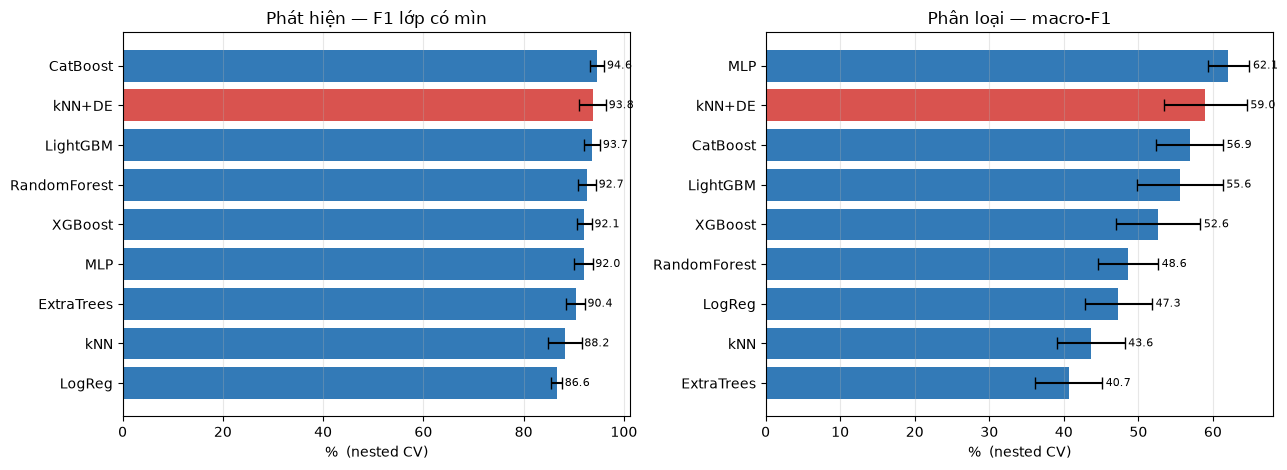

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, (tbl, res, key, title) in zip(axes, [
        (tbl_det, res_det, "f1", "Phát hiện — F1 lớp có mìn"),
        (tbl_cls, res_cls, "f1", "Phân loại — macro-F1")]):
    order = tbl["Mô hình"].tolist()
    means = [res[m][key].mean()*100 for m in order]
    errs  = [res[m][key].std()*100  for m in order]
    colors = ["#d9534f" if m=="kNN+DE" else "#337ab7" for m in order]
    ax.barh(order[::-1], means[::-1], xerr=errs[::-1], capsize=4, color=colors[::-1])
    for i,(mu,e) in enumerate(zip(means[::-1], errs[::-1])):
        ax.text(mu+e+0.5, i, f"{mu:.1f}", va="center", fontsize=8)
    ax.set_xlabel("%  (nested CV)"); ax.set_title(title); ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.savefig("../result/figures/04_so_sanh_mo_hinh.png", bbox_inches="tight"); plt.show()

## 8. Đường cong Precision–Recall cho PHÁT HIỆN (chọn ngưỡng an toàn)

Accuracy không cho biết ta có thể "không bỏ sót mìn" đến đâu. Đường PR (từ dự đoán out-of-fold) cho thấy: ở mức **recall = 100% (bắt hết mìn)**, precision còn bao nhiêu — tức phải chịu bao nhiêu báo động giả. Mô hình có `predict_proba` cho phép chỉnh ngưỡng này; đây là lý do thực tế để ưu tiên boosting.

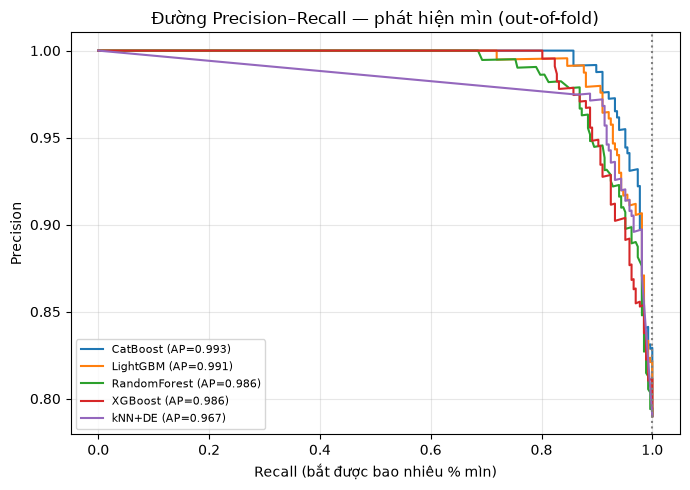

Precision khi recall = 100% (bắt hết mìn):
  CatBoost      : 82.9%
  LightGBM      : 82.2%
  RandomForest  : 79.5%
  XGBoost       : 81.2%
  kNN+DE        : 79.0%


In [8]:
def oof_proba(model_name, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    proba = np.zeros(len(y)); facs = build_factories()
    for tr, te in skf.split(X, y):
        s = StandardScaler().fit(X[tr]); Xtr, Xte = s.transform(X[tr]), s.transform(X[te])
        if model_name == "kNN+DE":
            Xit,Xiv,yit,yiv = train_test_split(Xtr,y[tr],test_size=0.25,stratify=y[tr],random_state=RANDOM_STATE)
            k,m,w = select_and_weight(Xit,yit,Xiv,yiv)
            knn = KNeighborsClassifier(n_neighbors=k, weights="distance").fit(Xtr*w, y[tr])
            proba[te] = knn.predict_proba(Xte*w)[:, list(knn.classes_).index(1)]
        else:
            mdl = facs[model_name].fit(Xtr, y[tr]) if False else facs[model_name]()
            mdl.fit(Xtr, y[tr])
            proba[te] = mdl.predict_proba(Xte)[:, list(mdl.classes_).index(1)]
    return proba

# chọn tối đa 4 mô hình đầu bảng phát hiện (có proba) + kNN+DE
cand = [m for m in tbl_det["Mô hình"] if m != "kNN+DE"][:4] + ["kNN+DE"]
plt.figure(figsize=(7,5))
for name in cand:
    p = oof_proba(name, X_all, y_detect)
    prec, rec, _ = precision_recall_curve(y_detect, p)
    ap = average_precision_score(y_detect, p)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
plt.axvline(1.0, ls=":", color="gray")
plt.xlabel("Recall (bắt được bao nhiêu % mìn)"); plt.ylabel("Precision")
plt.title("Đường Precision–Recall — phát hiện mìn (out-of-fold)")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("../result/figures/04_pr_curve_phat_hien.png", bbox_inches="tight"); plt.show()

# precision khi ép recall = 100% (không bỏ sót mìn nào)
print("Precision khi recall = 100% (bắt hết mìn):")
for name in cand:
    p = oof_proba(name, X_all, y_detect)
    prec, rec, _ = precision_recall_curve(y_detect, p)
    pr_at_full = prec[rec >= 0.999].max() if (rec >= 0.999).any() else float("nan")
    print(f"  {name:14s}: {pr_at_full*100:4.1f}%")

## 9. Kiểm định thống kê

Friedman: cả nhóm có khác biệt không? Wilcoxon ghép cặp: mô hình đầu bảng vs k-NN+DE có khác biệt thật không? (Hậu kiểm Nemenyi + CD diagram để ton tại nhóm tương đương sẽ làm ở Giai đoạn 5.)

In [9]:
for task, res, metric in [("PHÁT HIỆN", res_det, "f1"), ("PHÂN LOẠI", res_cls, "f1")]:
    order = sorted(res, key=lambda n: -res[n][metric].mean())
    M = np.column_stack([res[n][metric] for n in order])
    st, p = friedmanchisquare(*[M[:,i] for i in range(len(order))])
    print(f"{task}: Friedman chi2={st:.1f}, p={p:.2e} -> "
          f"{'có khác biệt (p<0.05)' if p<0.05 else 'chưa đủ bằng chứng'}")
    best = order[0]
    if best != "kNN+DE":
        _, pw = wilcoxon(res[best][metric], res["kNN+DE"][metric])
        print(f"   Wilcoxon {best} vs kNN+DE: p={pw:.3f} -> "
              f"{'khác biệt' if pw<0.05 else 'CHƯA tách biệt (coi như tương đương)'}")
    print()

PHÁT HIỆN: Friedman chi2=74.2, p=7.29e-13 -> có khác biệt (p<0.05)
   Wilcoxon CatBoost vs kNN+DE: p=0.196 -> CHƯA tách biệt (coi như tương đương)

PHÂN LOẠI: Friedman chi2=92.7, p=1.30e-16 -> có khác biệt (p<0.05)
   Wilcoxon MLP vs kNN+DE: p=0.048 -> khác biệt



## 10. Bảng khuyến nghị mô hình

Tổng hợp từ kết quả trên. Điểm mấu chốt: ở nhiều nhiệm vụ các mô hình đầu bảng **ngang nhau trong sai số** — nên chọn theo **tiêu chí phụ** (xác suất để chỉnh ngưỡng, độ bền dữ liệu nhỏ, triển khai).

In [10]:
best_det_f1  = tbl_det.iloc[0]["Mô hình"]
best_det_rec = tbl_det.sort_values("Recall(mìn)", ascending=False).iloc[0]["Mô hình"]
best_cls_f1  = tbl_cls.iloc[0]["Mô hình"]

khuyen_nghi = pd.DataFrame([
    ["Sản phẩm dùng CHUNG 1 mô hình", "Gradient boosting (CatBoost / LightGBM)",
     "Top/ngang-top cả 2 nhiệm vụ; có predict_proba để chỉnh ngưỡng theo recall; bền với dữ liệu nhỏ; không có khâu tối ưu trọng số dễ rò rỉ"],
    ["Chỉ PHÁT HIỆN", f"{best_det_f1} (đầu bảng F1) — ưu tiên boosting nếu nhóm đầu ngang nhau",
     "An toàn tính mạng → ưu tiên recall; xác suất cho phép ép recall→100% và đọc precision đánh đổi (xem mục 8)"],
    ["Chỉ PHÂN LOẠI", f"{best_cls_f1} (đầu bảng) hoặc boosting",
     "Mọi mô hình đều yếu (~55-63%); nếu ưu tiên accuracy đỉnh chọn đầu bảng, nếu ưu tiên nhất quán/xác suất chọn boosting; nên trả top-2 dự đoán"],
    ["KHÔNG nên dùng", "plain kNN, LogReg, ExtraTrees, RandomForest",
     "Yếu rõ (nhất là tree ensemble: chỉ 3 đặc trưng không đủ chiều)"],
    ["k-NN+DE (bài báo)", "không ưu tiên",
     "Cạnh tranh nhưng không vượt trội; xác suất kém; mang gánh nặng rò rỉ trọng số"],
], columns=["Tình huống", "Khuyến nghị", "Lý do"])
import pandas as pd
pd.set_option("display.max_colwidth", 80)
print(khuyen_nghi.to_string(index=False))

                   Tình huống                                                       Khuyến nghị                                                                                                                                       Lý do
Sản phẩm dùng CHUNG 1 mô hình                           Gradient boosting (CatBoost / LightGBM)      Top/ngang-top cả 2 nhiệm vụ; có predict_proba để chỉnh ngưỡng theo recall; bền với dữ liệu nhỏ; không có khâu tối ưu trọng số dễ rò rỉ
                Chỉ PHÁT HIỆN CatBoost (đầu bảng F1) — ưu tiên boosting nếu nhóm đầu ngang nhau                                  An toàn tính mạng → ưu tiên recall; xác suất cho phép ép recall→100% và đọc precision đánh đổi (xem mục 8)
                Chỉ PHÂN LOẠI                                      MLP (đầu bảng) hoặc boosting Mọi mô hình đều yếu (~55-63%); nếu ưu tiên accuracy đỉnh chọn đầu bảng, nếu ưu tiên nhất quán/xác suất chọn boosting; nên trả top-2 dự đoán
               KHÔNG nên dùng                       plai

## Tổng kết Giai đoạn 4

- So sánh k-NN+DE (bài báo) với mô hình hiện đại **trên cùng khung nested CV**, đo **nhiều chỉ số** (không chỉ accuracy): recall/precision/F1 + PR curve cho phát hiện, macro-F1 cho phân loại.
- **Khuyến nghị: gradient boosting (CatBoost/LightGBM)** làm lựa chọn chính — top/ngang-top cả hai nhiệm vụ, có xác suất để chỉnh ngưỡng theo recall (then chốt cho bài toán mìn), bền và không rò rỉ. MLP là lựa chọn thay thế cho phân loại nếu ưu tiên accuracy đỉnh.
- **Đọc kết quả đúng cách:** nhóm đầu bảng thường ngang nhau trong sai số; kết luận vững là "chọn theo tiêu chí phụ", không phải "mô hình X thắng tuyệt đối". Friedman xác nhận cả nhóm khác biệt; Wilcoxon so cặp trực tiếp.
- **Thông điệp cho đồ án:** với 338 mẫu và 3 đặc trưng, không mô hình phức tạp nào vượt trội áp đảo — bản thân đó là kết luận giá trị, và phương pháp 2018 (k-NN+DE) *sau khi bỏ rò rỉ* chỉ ngang, không hơn, các lựa chọn hiện đại.

## Sang Giai đoạn 5
Hậu kiểm **Nemenyi + critical difference diagram** để xác định chính xác nhóm mô hình không tách biệt được — cách trình bày chuẩn khi so sánh nhiều mô hình trên dữ liệu ít.